# Plot Data Extracted from the OVL portal

The objective of this Jupyter notebook is to show how to plot a npy object extracted using the OVL portal using python.


Necessary modules are:
* numpy
* cartopy
* matplotlib
* jupyter-lab (to run this notebook)

## Imports

In [1]:
import numpy
import re
import os
import cartopy
from matplotlib import pyplot
%matplotlib inline

## Load data
* Extract datasets of interest in a rectangle in a npy format from the ovl portal.
* Download the relevant npy extractions, the filename contains the coordinates of the corner of the box.

In [18]:
def extract_lon_lat(filename):
    # Extract lat and lon values from the filename using regex
    filename, _ = os.path.splitext(filename)
    lat_match = re.search(r'lat_([-\d.]+)_([-\d.]+)', filename)
    lon_match = re.search(r'lon_([-\d.]+)_([-\d.]+)', filename)
    
    if lat_match and lon_match:
        lat_min = float(lat_match.group(1))
        lat_max = float(lat_match.group(2))
        lon_min = float(lon_match.group(1))
        lon_max = float(lon_match.group(2))
        
        print(f"Latitude range: {lat_min} to {lat_max}")
        print(f"Longitude range: {lon_min} to {lon_max}")
    else:
        print("Could not extract coordinates")
    return lon_min, lon_max, lat_min, lat_max

def corners_to_merc(box):
    # Define projections
    merc = cartopy.crs.Mercator()
    plate = cartopy.crs.PlateCarree()    
    lon_min, lon_max, lat_min, lat_max = box
    # Convert lon/lat corners to Mercator (x, y in meters)
    # Note: transform_point expects (lon, lat) → returns (x, y)
    x_min, y_min = merc.transform_point(lon_min, lat_min, src_crs=plate)
    x_max, y_max = merc.transform_point(lon_max, lat_max, src_crs=plate)
    
    # Your Mercator-projected data extent (in meters)
    box_merc = [x_min, x_max, y_min, y_max]
    return box_merc, merc

In [42]:
# Change your input directory
WDIR = '/Users/lgaultier/Downloads'
# Change the files extracted from your rectangle
listfile = ['3857_Sentinel-1A_SAR_roughness-s1a-iw-grd-vv-20251119t180450-20251119t180515-061950-07bf6a-001-3EA3-lat_47.1253_47.4086_lon_-3.2684_-2.5735.npy',
            '3857_Sentinel-1A_SAR_roughness-s1a-iw-grd-vv-20251119t180515-20251119t180540-061950-07bf6a-001-CDA1-lat_47.1253_47.4086_lon_-3.2684_-2.5735.npy']

data = []
for filename in listfile:
    box = extract_lon_lat(filename)
    _data = numpy.load(os.path.join(WDIR, filename))
    _data = numpy.ma.masked_values(_data, 255)
    _data = numpy.ma.masked_values(_data, 0)

    data.append(_data)


Latitude range: 47.1253 to 47.4086
Longitude range: -3.2684 to -2.5735
Latitude range: 47.1253 to 47.4086
Longitude range: -3.2684 to -2.5735


## Plot data in Mercator projection
Loop over the list of files to plot all datasets in Mercator projections

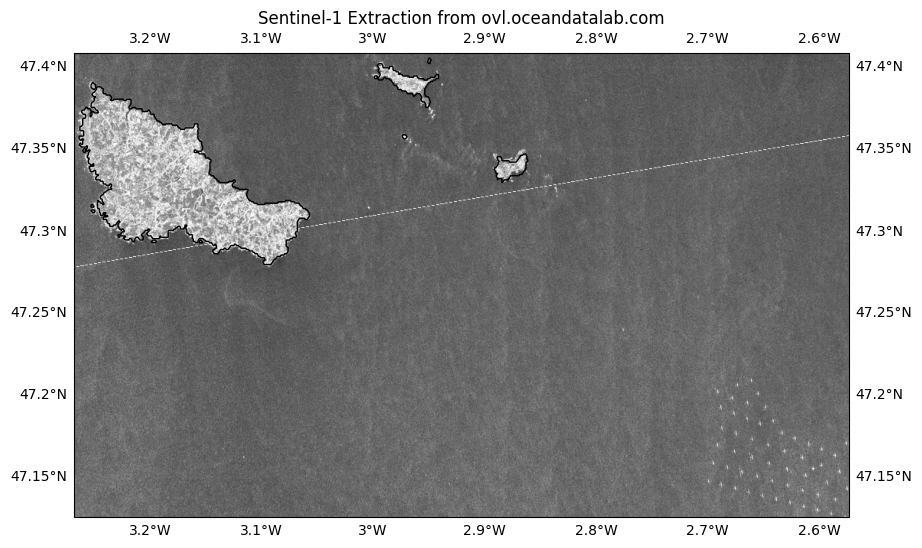

In [51]:
# Get Corners in Mercator Projection
box_merc, merc = corners_to_merc(box)

figure = pyplot.figure(figsize=(10, 8))
ax = pyplot.axes(projection=merc)

ax.set_extent(box_merc, crs=merc)
gl = ax.gridlines(draw_labels=True,
                  linewidth=2, color='gray', alpha=0.1, linestyle='--')
for _data in data[::-1]:
    ax.imshow(_data, origin='upper', extent=box_merc, transform=merc, cmap='gray', alpha=0.8)
coast = cartopy.feature.GSHHSFeature(scale='f')
ax.add_feature(coast)
#ax.coastlines(resolution='50m', color='blue', linewidth=100)
pyplot.title('Sentinel-1 Extraction from ovl.oceandatalab.com')
pyplot.savefig('plot_with_coastline.png')